In [31]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import linregress

rd = Path.cwd().parent/'data'/'raw'
wd = Path.cwd().parent/'reports'


In [32]:
nav = pd.read_csv(
    rd/"02_nav_history.csv"
)

perf = pd.read_csv(
    rd/"07_scheme_performance.csv"
)

benchmark = pd.read_csv(
    rd/"10_benchmark_indices.csv"
)

In [33]:
nav["date"] = pd.to_datetime(
    nav["date"]
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

In [34]:
nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

In [35]:
nav.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


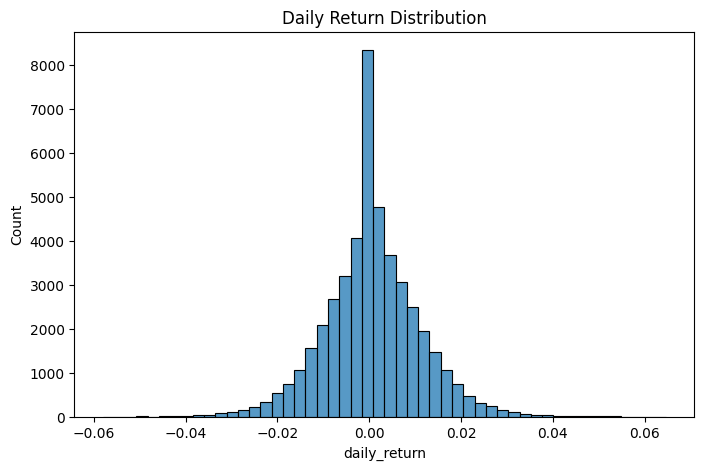

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50
)

plt.title(
    "Daily Return Distribution"
)

plt.show()

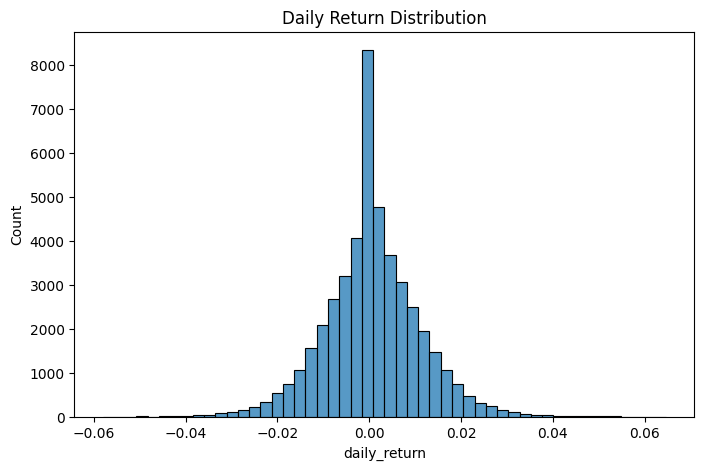

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50
)

plt.title(
    "Daily Return Distribution"
)

plt.savefig(
    wd/"daily_return_distribution.png"
)

plt.show()

In [38]:
nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


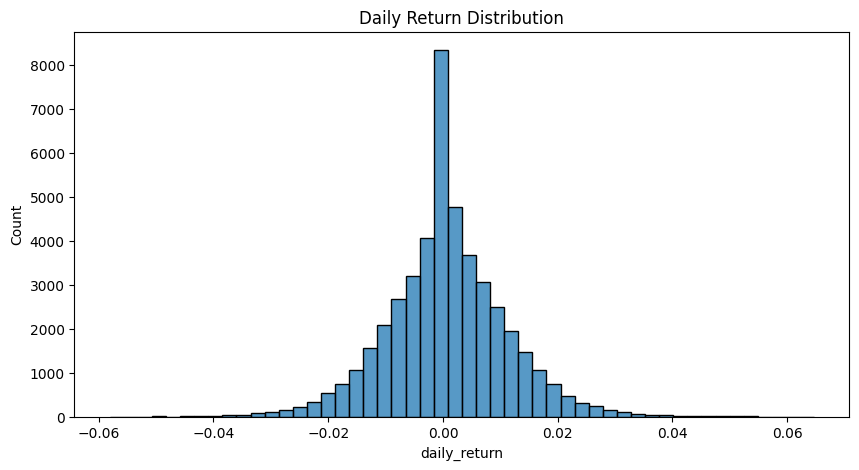

In [39]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50
)

plt.title("Daily Return Distribution")

plt.savefig(
    wd/"daily_return_distribution.png"
)

plt.show()

In [40]:
cagr_table = perf[
[
    "amfi_code",
    "scheme_name",
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct"
]
]

cagr_table.head()

,amfi_code,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.42,12.36,14.45
1,119552,SBI Bluechip Fund - Direct Plan - Growth,15.25,11.30,14.23
2,119598,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67
3,119599,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,6.07,5.43


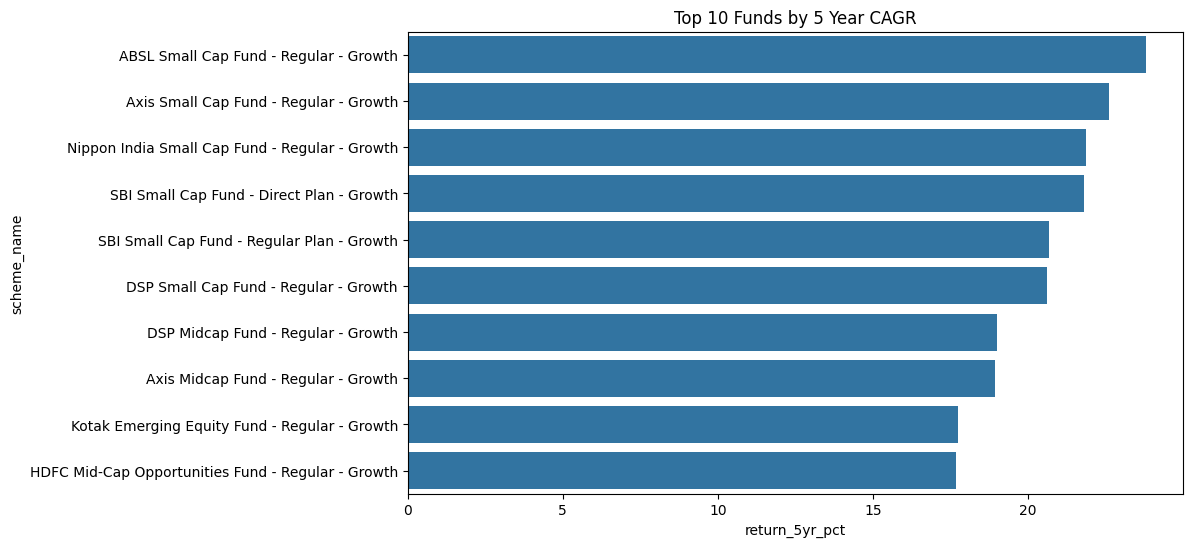

In [41]:
top_cagr = perf.nlargest(
    10,
    "return_5yr_pct"
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_cagr,
    x="return_5yr_pct",
    y="scheme_name"
)

plt.title(
    "Top 10 Funds by 5 Year CAGR"
)

plt.savefig(
    wd/"top_5yr_cagr.png"
)

plt.show()

In [42]:
sharpe_rank = perf[
[
    "scheme_name",
    "sharpe_ratio"
]
].sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_rank.head(10)

,scheme_name,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03
15,Nippon India Large Cap Fund - Regular - Growth,1.00


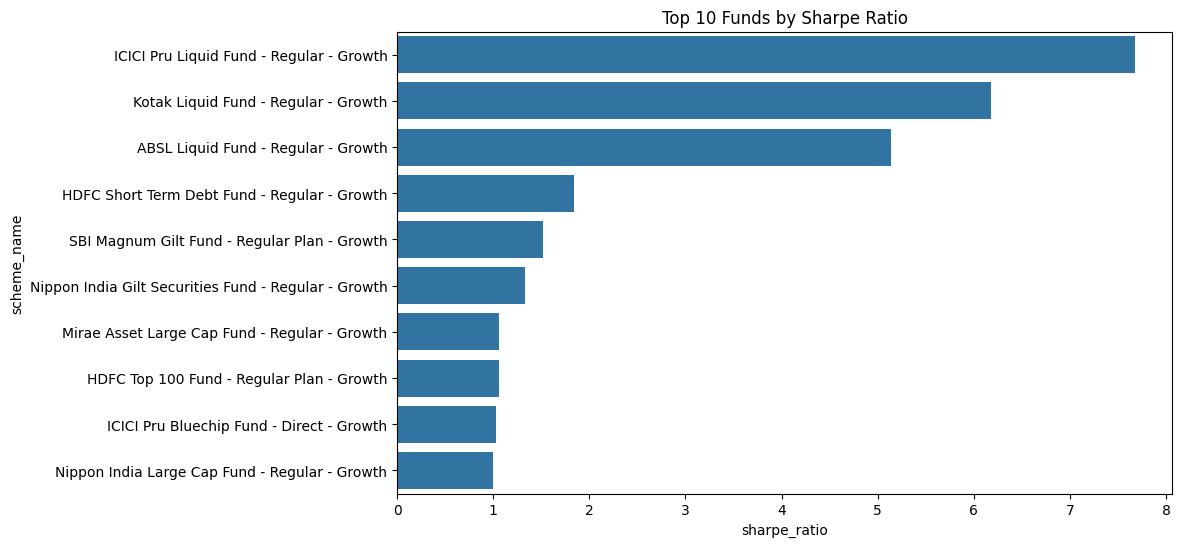

In [43]:
top_sharpe = sharpe_rank.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_sharpe,
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title(
    "Top 10 Funds by Sharpe Ratio"
)

plt.savefig(
    wd/"top_sharpe_ratio.png"
)

plt.show()

In [44]:
perf[[
    "scheme_name",
    "sortino_ratio"
]].sort_values(
    "sortino_ratio",
    ascending=False
).head(10)

,scheme_name,sortino_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,10.37
23,Kotak Liquid Fund - Regular - Growth,9.70
30,ABSL Liquid Fund - Regular - Growth,8.76
9,HDFC Short Term Debt Fund - Regular - Growth,2.79
19,Nippon India Gilt Securities Fund - Regular - ...,2.38
4,SBI Magnum Gilt Fund - Regular Plan - Growth,2.11
5,HDFC Top 100 Fund - Regular Plan - Growth,1.70
15,Nippon India Large Cap Fund - Regular - Growth,1.68
3,SBI Small Cap Fund - Direct Plan - Growth,1.67
34,Mirae Asset Large Cap Fund - Regular - Growth,1.66


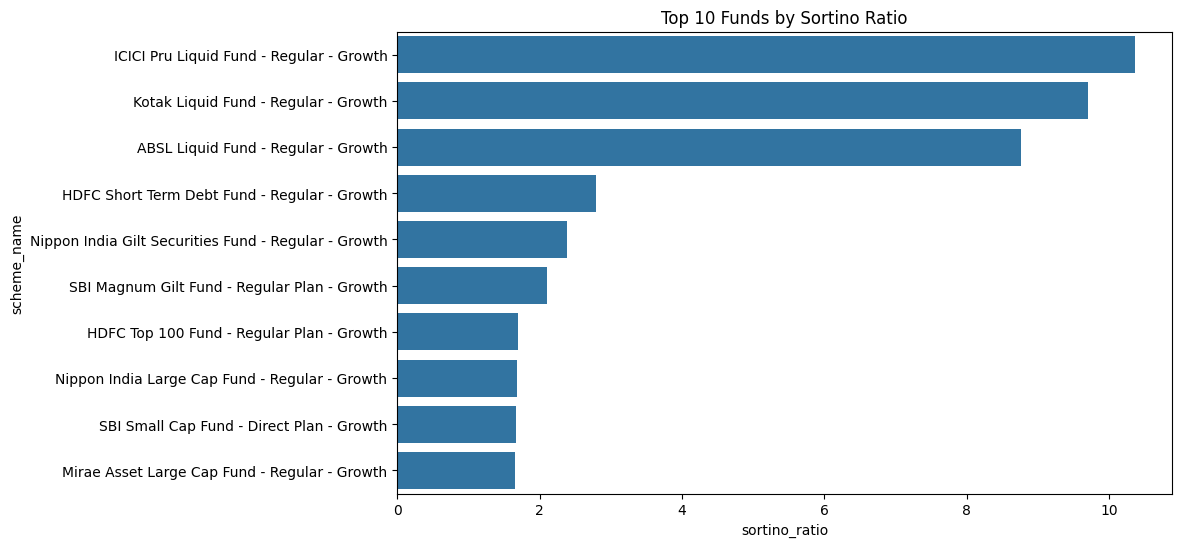

In [45]:
top_sortino = perf.nlargest(
    10,
    "sortino_ratio"
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_sortino,
    x="sortino_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.savefig(
    wd/"top_sortino_ratio.png"
)

plt.show()

In [46]:
perf[[
    "scheme_name",
    "alpha",
    "beta"
]].head()

,scheme_name,alpha,beta
0,SBI Bluechip Fund - Regular Plan - Growth,0.87,0.89
1,SBI Bluechip Fund - Direct Plan - Growth,1.78,0.87
2,SBI Small Cap Fund - Regular Plan - Growth,1.23,0.89
3,SBI Small Cap Fund - Direct Plan - Growth,1.13,1.04
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.60,0.22


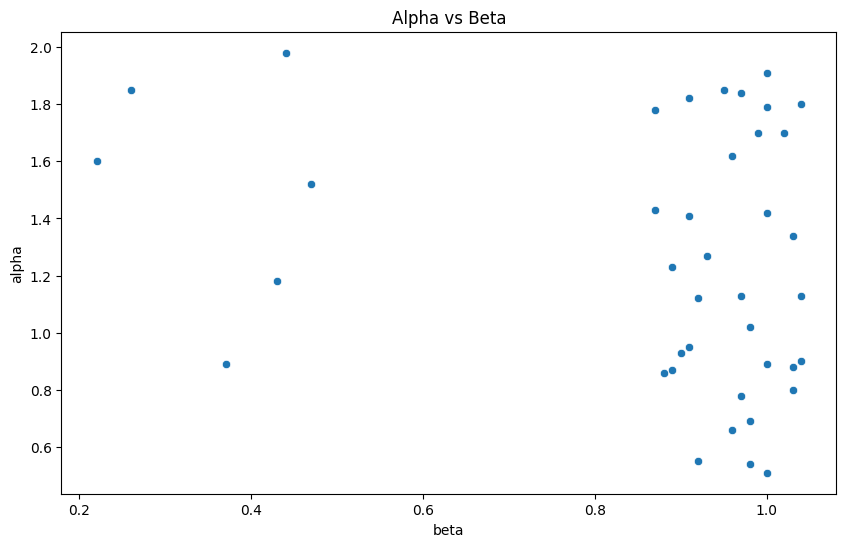

In [47]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=perf,
    x="beta",
    y="alpha"
)

plt.title(
    "Alpha vs Beta"
)

plt.savefig(
    wd/"alpha_beta.png"
)

plt.show()

In [48]:
top_dd = perf.sort_values(
    "max_drawdown_pct"
).head(10)

top_dd[[
    "scheme_name",
    "max_drawdown_pct"
]]

,scheme_name,max_drawdown_pct
6,HDFC Top 100 Fund - Direct Plan - Growth,-33.50
35,Mirae Asset Emerging Bluechip Fund - Regular -...,-33.15
26,Axis Midcap Fund - Regular - Growth,-32.38
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,-32.22
17,Nippon India Small Cap Fund - Regular - Growth,-30.87
24,Axis Bluechip Fund - Regular - Growth,-27.54
38,DSP Midcap Fund - Regular - Growth,-26.99
18,Nippon India ETF Nifty 50 BeES,-26.75
11,ICICI Pru Bluechip Fund - Direct - Growth,-26.59
10,ICICI Pru Bluechip Fund - Regular - Growth,-25.91


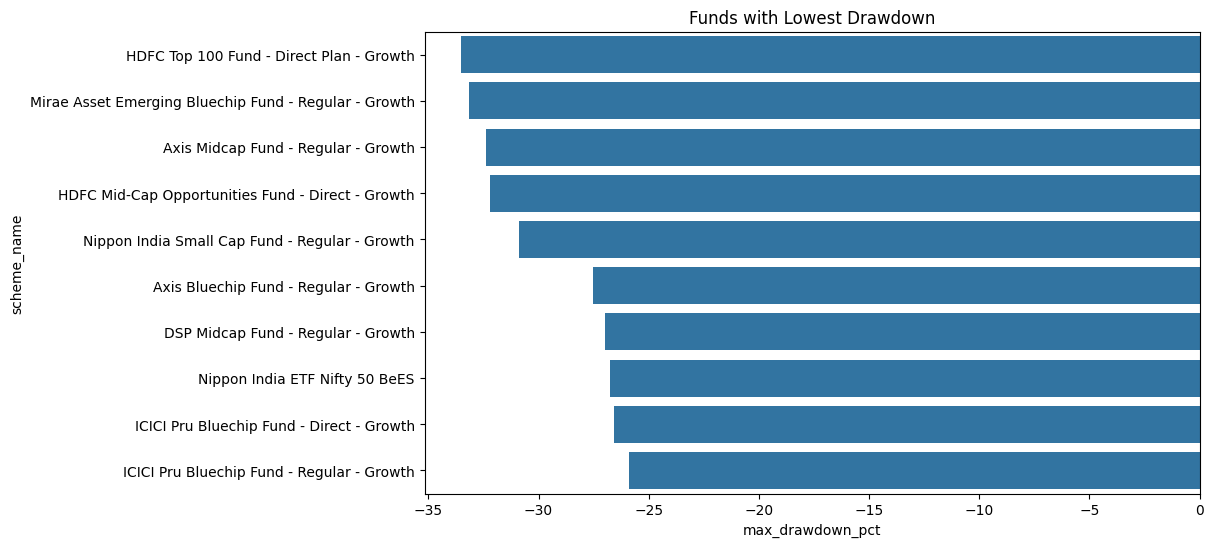

In [49]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_dd,
    x="max_drawdown_pct",
    y="scheme_name"
)

plt.title(
    "Funds with Lowest Drawdown"
)

plt.savefig(
    wd/"max_drawdown.png"
)

plt.show()

In [50]:
scorecard = perf.copy()

scorecard["rank_return"] = scorecard["return_3yr_pct"].rank(
    ascending=False
)

scorecard["rank_sharpe"] = scorecard["sharpe_ratio"].rank(
    ascending=False
)

scorecard["rank_alpha"] = scorecard["alpha"].rank(
    ascending=False
)

scorecard["rank_expense"] = scorecard["expense_ratio_pct"].rank(
    ascending=True
)

scorecard["rank_drawdown"] = scorecard["max_drawdown_pct"].rank(
    ascending=True
)

In [51]:
scorecard["fund_score"] = (

      scorecard["rank_return"] * 0.30
    + scorecard["rank_sharpe"] * 0.25
    + scorecard["rank_alpha"] * 0.20
    + scorecard["rank_expense"] * 0.15
    + scorecard["rank_drawdown"] * 0.10

)

In [52]:
best_funds = scorecard.sort_values(
    "fund_score"
)

best_funds[
[
    "scheme_name",
    "fund_score"
]
].head(10)

,scheme_name,fund_score
3,SBI Small Cap Fund - Direct Plan - Growth,11.900
22,Kotak Flexicap Fund - Regular - Growth,12.400
21,Kotak Emerging Equity Fund - Regular - Growth,12.800
29,ABSL Small Cap Fund - Regular - Growth,13.700
2,SBI Small Cap Fund - Regular Plan - Growth,15.250
34,Mirae Asset Large Cap Fund - Regular - Growth,15.425
9,HDFC Short Term Debt Fund - Regular - Growth,15.800
14,ICICI Pru Liquid Fund - Regular - Growth,16.300
12,ICICI Pru Midcap Fund - Regular - Growth,16.600
11,ICICI Pru Bluechip Fund - Direct - Growth,17.150


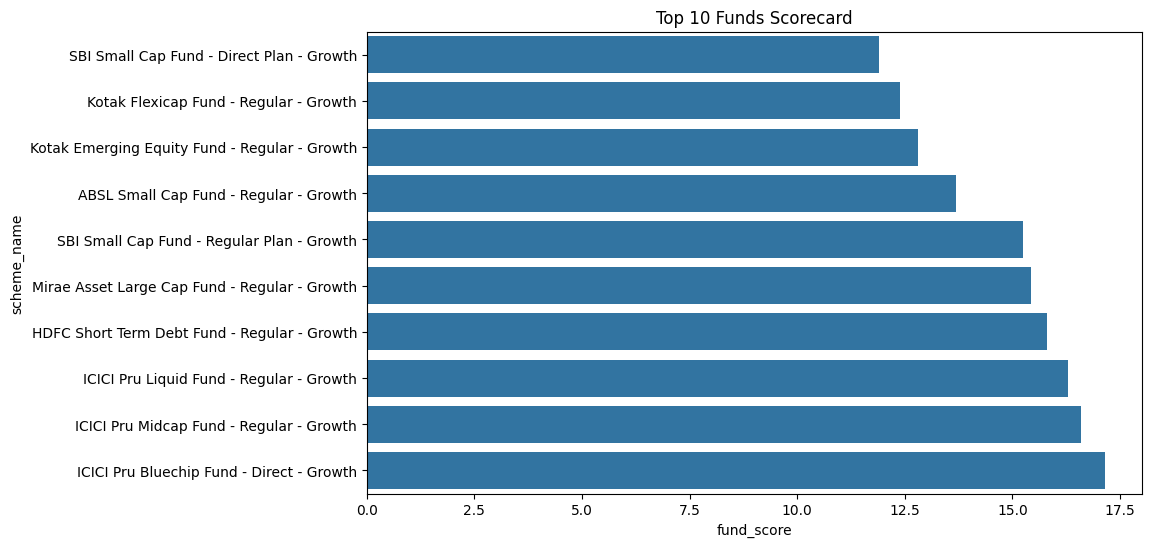

In [53]:
top_funds = best_funds.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_funds,
    x="fund_score",
    y="scheme_name"
)

plt.title(
    "Top 10 Funds Scorecard"
)

plt.savefig(
    wd/"fund_scorecard.png"
)

plt.show()

In [54]:
scorecard.to_csv(
    wd/"fund_scorecard.csv",
    index=False
)

print("Saved")

Saved


In [55]:
top5 = scorecard.sort_values(
    "fund_score"
).head(5)

top5[[
    "scheme_name",
    "amfi_code"
]]

,scheme_name,amfi_code
3,SBI Small Cap Fund - Direct Plan - Growth,119599
22,Kotak Flexicap Fund - Regular - Growth,120843
21,Kotak Emerging Equity Fund - Regular - Growth,120842
29,ABSL Small Cap Fund - Regular - Growth,101207
2,SBI Small Cap Fund - Regular Plan - Growth,119598


In [56]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [57]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [58]:
top5 = scorecard.sort_values(
    "fund_score"
).head(5)

top5[[
    "scheme_name",
    "amfi_code"
]]

,scheme_name,amfi_code
3,SBI Small Cap Fund - Direct Plan - Growth,119599
22,Kotak Flexicap Fund - Regular - Growth,120843
21,Kotak Emerging Equity Fund - Regular - Growth,120842
29,ABSL Small Cap Fund - Regular - Growth,101207
2,SBI Small Cap Fund - Regular Plan - Growth,119598


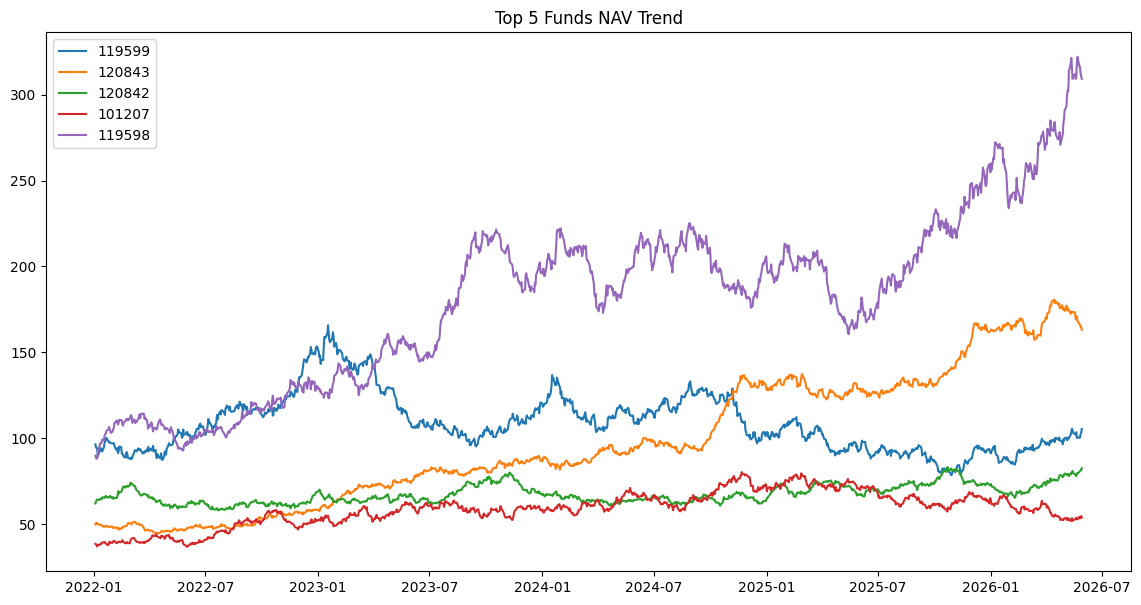

In [59]:
top_codes = top5["amfi_code"].tolist()

top_nav = nav[
    nav["amfi_code"].isin(top_codes)
]

plt.figure(figsize=(14,7))

for code in top_codes:

    temp = top_nav[
        top_nav["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(code)
    )

plt.legend()

plt.title(
    "Top 5 Funds NAV Trend"
)

plt.show()

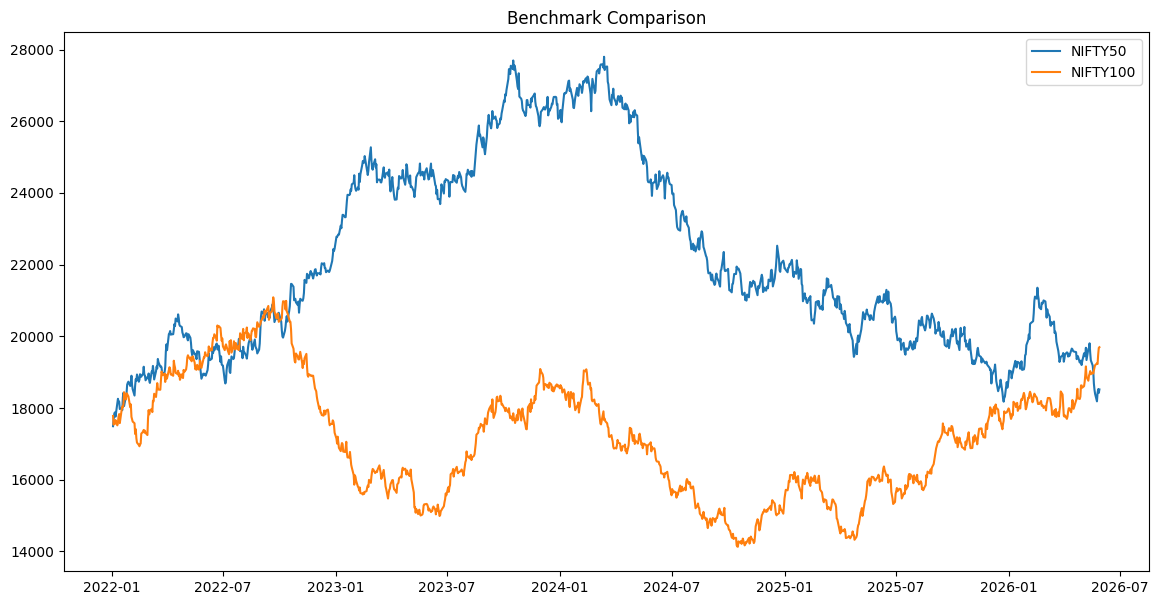

In [60]:
bench = benchmark[
    benchmark["index_name"].isin(
        ["NIFTY50","NIFTY100"]
    )
]

plt.figure(figsize=(14,7))

for idx in ["NIFTY50","NIFTY100"]:

    temp = bench[
        bench["index_name"] == idx
    ]

    plt.plot(
        temp["date"],
        temp["close_value"],
        label=idx
    )

plt.legend()

plt.title(
    "Benchmark Comparison"
)

plt.savefig(
    wd/"benchmark_comparison.png"
)

plt.show()

In [61]:
perf[[
    "amfi_code",
    "scheme_name",
    "alpha",
    "beta"
]].to_csv(
    wd/"alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


# Performance Analytics Findings

### Insight 1
ICICI Pru Liquid Fund achieved the highest Sharpe Ratio.

### Insight 2
Small Cap funds delivered the highest long-term CAGR.

### Insight 3
Funds with higher alpha generally showed better performance.

### Insight 4
Several large-cap funds maintained lower drawdowns.

### Insight 5
Risk-adjusted performance varies significantly across fund categories.

### Insight 6
Top-ranked funds consistently score well across CAGR, Sharpe Ratio, and Alpha metrics.
